## Shoppers spectrum: Customer segementation and Product recommendation


#### STEP 1 Data Collection and Understanding

In [106]:
# import libraries and load dataset
import pandas as pd
import numpy as np

df = pd.read_csv(r"C:\Users\user\Documents\guvi\guvi project 1\fourth_project\online_retail.csv")

print("Dataset loaded.")
print("Shape:", df.shape)
print("Columns:", list(df.columns))

Dataset loaded.
Shape: (541909, 8)
Columns: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


In [107]:
# Overview of datast

print("\nTop 5 rows:")
display(df.head())

print("\nDataset info (data types, missing values):")
df.info()

# Check Data types and nulls per column

print("\nNull values per column:")
print(df.isna().sum())

print("\n% of data missing per column:")
print((df.isna().sum() / len(df)) * 100)


Top 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850.0,United Kingdom



Dataset info (data types, missing values):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB

Null values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

% of data missing per column:
InvoiceNo       0.000000
StockCode       0.000000
Description     0.268311
Quantity        0.000000
InvoiceD

In [108]:
# check Duplicates
print("\nChecking for exact duplicate rows:")

n_dups = df.duplicated().sum()
print(f"Number of duplicate rows = {n_dups}")

if n_dups > 0:
    print("\nSample duplicate rows:")
    display(df[df.duplicated(keep='first')].head())


Checking for exact duplicate rows:
Number of duplicate rows = 5268

Sample duplicate rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2022-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2022-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2022-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2022-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2022-12-01 11:49:00,2.95,17920.0,United Kingdom


In [109]:
# Check Unusual / suspicious records

print("\nUnusual records checks:")

# Check the Missing CustomerID
missing_cid = df["CustomerID"].isna() if "CustomerID" in df.columns else pd.Series([False]*len(df))
n_missing_cid = missing_cid.sum()
print(f"Rows with missing CustomerID = {n_missing_cid}")

# Check the Negative or zero Quantity
if "Quantity" in df.columns:
    n_neg_qty = (df["Quantity"] <= 0).sum()
    n_zero_qty = (df["Quantity"] == 0).sum()
    print(f"Negative quantity = {n_neg_qty}")
    print(f"Zero quantity     = {n_zero_qty}")

# Check the Negative UnitPrice 
if "UnitPrice" in df.columns:
    n_neg_price = (df["UnitPrice"] < 0).sum()
    print(f"Negative UnitPrice = {n_neg_price}")


Unusual records checks:
Rows with missing CustomerID = 135080
Negative quantity = 10624
Zero quantity     = 0
Negative UnitPrice = 2


#### STEP 2 Data Preprocessing

In [110]:
# Remove rows with missing CustomerID
print("Removing rows with missing CustomerID...")
print("Before:", len(df))

df = df.dropna(subset=["CustomerID"])
print("After:", len(df))
print()

Removing rows with missing CustomerID...
Before: 541909
After: 406829



In [111]:
# Exclude cancelled invoices (InvoiceNo starting with 'C')
print("Excluding cancelled invoices (InvoiceNo starting with 'C')...")

df["InvoiceNo_str"] = df["InvoiceNo"].astype(str)
mask_not_cancel = ~df["InvoiceNo_str"].str.lower().str.startswith("c", na=False)

print("Cancelled rows:", (~mask_not_cancel).sum())
df = df[mask_not_cancel].copy()
df = df.drop("InvoiceNo_str", axis=1)

print("Remaining rows:", len(df))
print()

Excluding cancelled invoices (InvoiceNo starting with 'C')...
Cancelled rows: 8905
Remaining rows: 397924



In [112]:
# Remove negative or zero Quantity
print("Removing negative or zero Quantity...")

q_mask = df["Quantity"] > 0
print("Rows with Quantity <= 0:", (~q_mask).sum())

df = df[q_mask]
print("Remaining rows:", len(df))
print()

# Remove negative UnitPrice
print("Removing negative UnitPrice...")

p_mask = df["UnitPrice"] > 0
print("Rows with negative UnitPrice:", (~p_mask).sum())

df = df[p_mask]
print("Remaining rows:", len(df))
print()


# Check the dataset after preprocessing
print("Final dataset shape (after preprocessing):", df.shape)
print("Quick info:")
df.info()

Removing negative or zero Quantity...
Rows with Quantity <= 0: 0
Remaining rows: 397924

Removing negative UnitPrice...
Rows with negative UnitPrice: 40
Remaining rows: 397884

Final dataset shape (after preprocessing): (397884, 8)
Quick info:
<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397884 non-null  object 
 1   StockCode    397884 non-null  object 
 2   Description  397884 non-null  object 
 3   Quantity     397884 non-null  int64  
 4   InvoiceDate  397884 non-null  object 
 5   UnitPrice    397884 non-null  float64
 6   CustomerID   397884 non-null  float64
 7   Country      397884 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.3+ MB


#### STEP 3 Exploratory Data Analysis(EDA)

In [113]:
# import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings("ignore")

Transaction volume by country
Top 10 countries by number of transactions:
Country
United Kingdom    361878
Germany             9495
France              8491
EIRE                7485
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         1877
Portugal            1480
Australia           1259
Name: count, dtype: int64


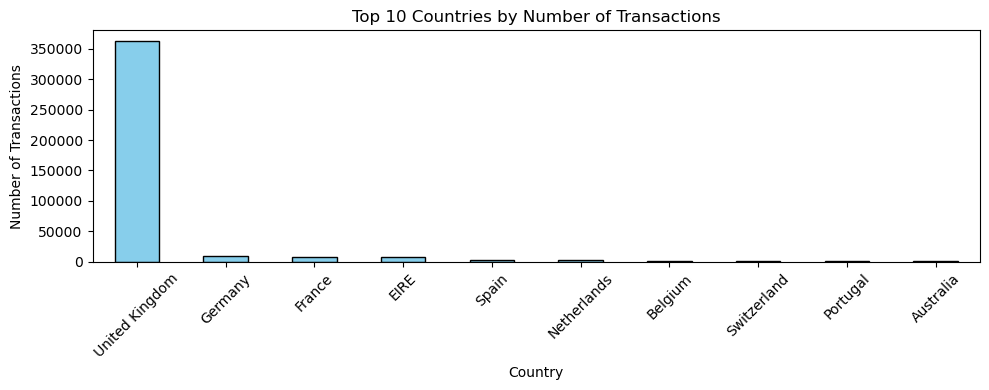

In [125]:
# 1. TRANSACTION VOLUME BY COUNTRY

print("Transaction volume by country")
print("Top 10 countries by number of transactions:")

country_counts = df["Country"].value_counts().head(10)
print(country_counts)

plt.figure(figsize=(10, 4))
country_counts.plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Top 10 Countries by Number of Transactions")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Top-selling products (by quantity)
StockCode  Description                       
23843      PAPER CRAFT , LITTLE BIRDIE           80995
23166      MEDIUM CERAMIC TOP STORAGE JAR        77916
84077      WORLD WAR 2 GLIDERS ASSTD DESIGNS     54415
85099B     JUMBO BAG RED RETROSPOT               46181
85123A     WHITE HANGING HEART T-LIGHT HOLDER    36725
84879      ASSORTED COLOUR BIRD ORNAMENT         35362
21212      PACK OF 72 RETROSPOT CAKE CASES       33693
22197      POPCORN HOLDER                        30931
23084      RABBIT NIGHT LIGHT                    27202
22492      MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


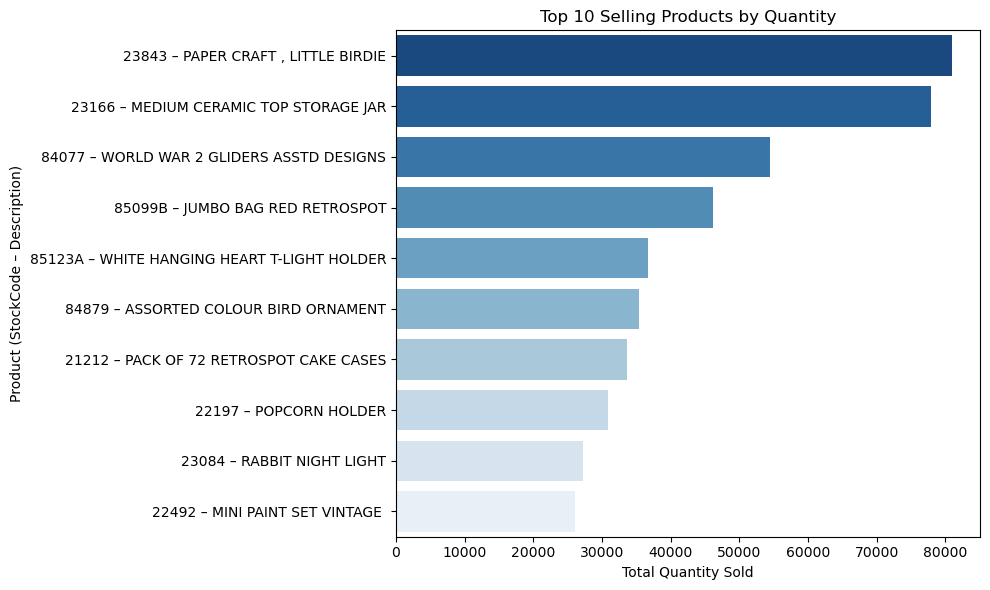

In [54]:
# 2. Top-selling products WITH StockCode

print("\nTop-selling products (by quantity)")
top_products = (
    df.groupby(["StockCode", "Description"])["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_products)

# Create a combined label for plotting (e.g., "StockCode – Description")
top_products_plot = top_products.reset_index()
top_products_plot["Product_Label"] = (
    top_products_plot["StockCode"] + " – " + top_products_plot["Description"]
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_products_plot,
    x="Quantity",
    y="Product_Label",
    palette="Blues_r"
)
plt.title("Top 10 Selling Products by Quantity")
plt.xlabel("Total Quantity Sold")
plt.ylabel("Product (StockCode – Description)")
plt.tight_layout()
plt.show()


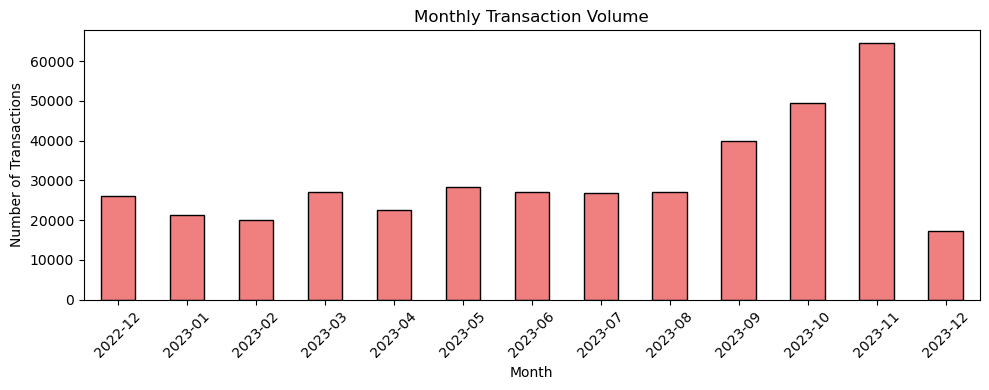

In [46]:
# 3. PURCHASE TRENDS OVER TIME
# Monthly trend

df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)
monthly_sales = df.groupby("Month").size()

plt.figure(figsize=(10, 4))
monthly_sales.plot(kind="bar", color="lightcoral", edgecolor="black")
plt.title("Monthly Transaction Volume")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



. Monetary analysis

Monetary per customer (top 10):
CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: TotalAmount, dtype: float64


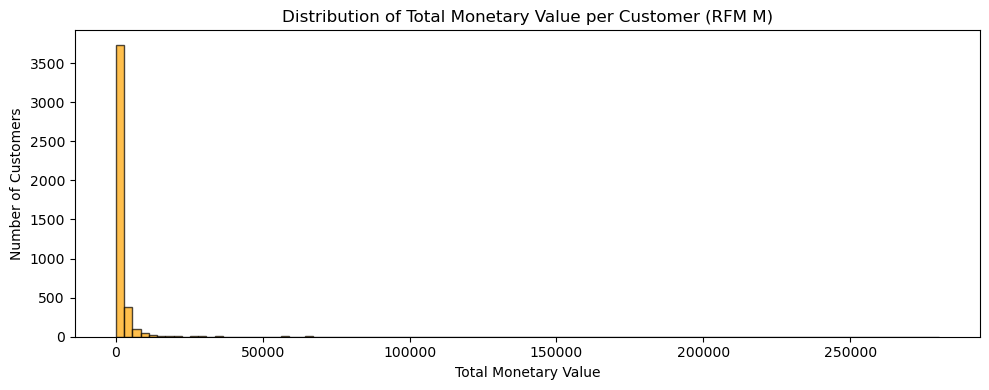

In [58]:
# 4. MONETARY ANALYSIS: PER-TRANSACTION & PER-CUSTOMER

print("\n. Monetary analysis")

# Per customer

cust_monetary = df.groupby("CustomerID")["TotalAmount"].sum()
print("\nMonetary per customer (top 10):")
print(cust_monetary.sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 4))
plt.hist(cust_monetary, bins=100, color="orange", alpha=0.7, edgecolor="black")
plt.title("Distribution of Total Monetary Value per Customer (RFM M)")
plt.xlabel("Total Monetary Value")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()


 RFM Feature Engineering


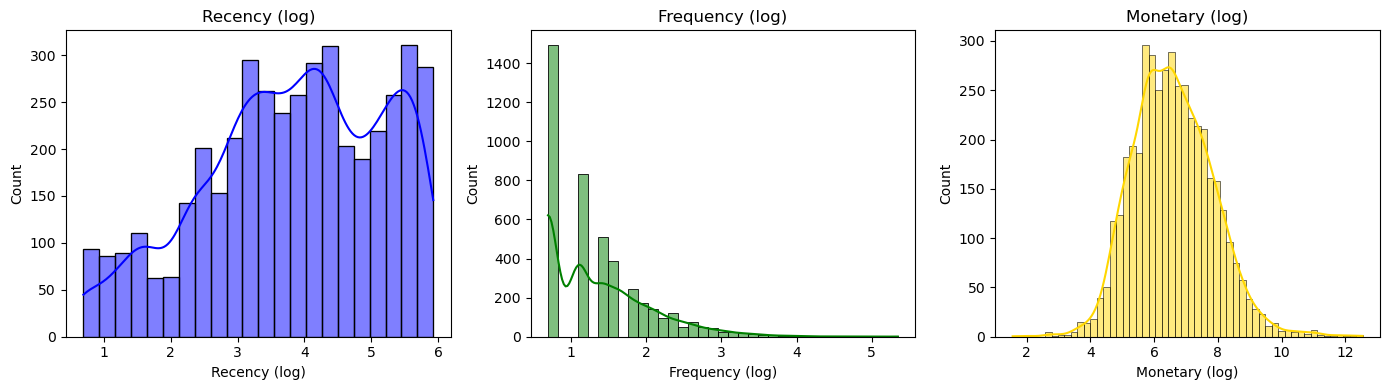

In [49]:
# 5. RFM FEATURE ENGINEERING

print("\n RFM Feature Engineering")

# Reference date for "Recency"
ref_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg(
    Recency=("InvoiceDate", lambda x: (ref_date - x.max()).days),
    Frequency=("InvoiceNo", "nunique"),
    Monetary=("TotalAmount", "sum"),
)

# Handle possible negative Recency (if any edge cases)
rfm = rfm[rfm["Recency"] >= 0]

# Log-transform to reduce skewness
rfm["Recency_log"] = np.log1p(rfm["Recency"])
rfm["Monetary_log"] = np.log1p(rfm["Monetary"])
rfm["Frequency_log"] = np.log1p(rfm["Frequency"])

# Plot RFM distributions
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.histplot(rfm["Recency_log"], ax=axes[0], kde=True, color="blue")
axes[0].set_title("Recency (log)")
axes[0].set_xlabel("Recency (log)")

sns.histplot(rfm["Frequency_log"], ax=axes[1], kde=True, color="green")
axes[1].set_title("Frequency (log)")
axes[1].set_xlabel("Frequency (log)")

sns.histplot(rfm["Monetary_log"], ax=axes[2], kde=True, color="gold")
axes[2].set_title("Monetary (log)")
axes[2].set_xlabel("Monetary (log)")

plt.tight_layout()
plt.show()


 Elbow Curve for Cluster Selection


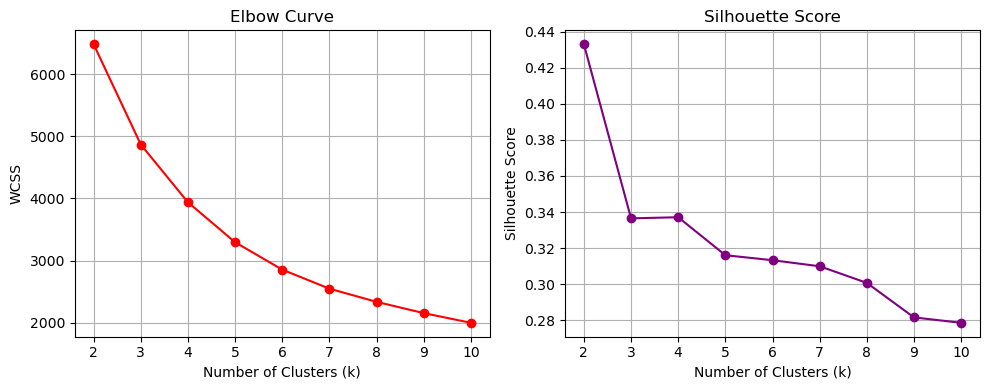

In [50]:
# 6. ELBOW CURVE FOR CLUSTER SELECTION (KMeans)

print("\n Elbow Curve for Cluster Selection")

features = ["Recency_log", "Frequency_log", "Monetary_log"]
X = rfm[features]

# Standardize features

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []
sil_scores = []

k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Elbow plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker="o", color="red")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Curve")
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_range, sil_scores, marker="o", color="purple")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score")
plt.grid(True)

plt.tight_layout()
plt.show()



 Customer Cluster Profiles (k=4)
Cluster profiles (mean, median, count):
        Recency_clean              Frequency_clean               \
                 mean median count            mean median count   
Cluster                                                           
1               12.13    8.0   716           13.71   10.0   716   
0               18.12   17.0   837            2.15    2.0   837   
2               71.08   56.0  1173            4.08    4.0  1173   
3              182.50  177.0  1612            1.32    1.0  1612   

        Monetary_clean                 
                  mean   median count  
Cluster                                
1              8074.27  3733.87   716  
0               551.82   471.70   837  
2              1802.83  1345.62  1173  
3               343.45   298.26  1612  


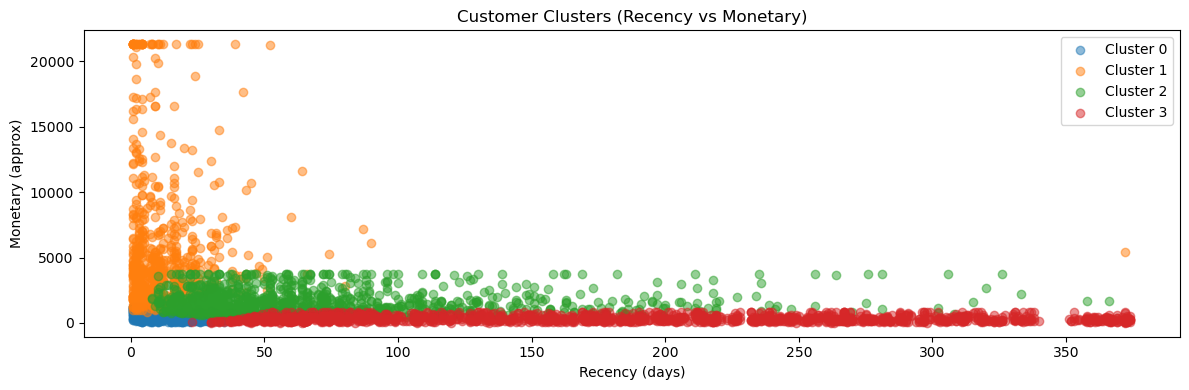

In [51]:
# 7. CUSTOMER CLUSTER PROFILES

print("\n Customer Cluster Profiles (k=4)")

k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
rfm["Cluster"] = kmeans.fit_predict(X_scaled)

# Reverse log back to approximate original scale for interpretation
rfm["Recency_clean"] = np.expm1(rfm["Recency_log"])
rfm["Monetary_clean"] = np.expm1(rfm["Monetary_log"])
rfm["Frequency_clean"] = np.expm1(rfm["Frequency_log"])

cluster_profiles = (
    rfm.groupby("Cluster")[["Recency_clean", "Frequency_clean", "Monetary_clean"]]
    .agg(["mean", "median", "count"])
    .round(2)
)

print("Cluster profiles (mean, median, count):")
print(cluster_profiles.sort_values(("Recency_clean", "mean")))


plt.figure(figsize=(12, 4))

for i in range(k):
    cluster_data = rfm[rfm["Cluster"] == i]
    r = np.clip(cluster_data["Recency_clean"], 0, 500)
    m = np.clip(cluster_data["Monetary_clean"], 0, cluster_data["Monetary_clean"].quantile(0.95))
    plt.scatter(r, m, alpha=0.5, label=f"Cluster {i}")

plt.xlabel("Recency (days)")
plt.ylabel("Monetary (approx)")
plt.title("Customer Clusters (Recency vs Monetary)")
plt.legend()
plt.tight_layout()
plt.show()



 Product Recommendation: Similarity Matrix (Item-Item)
Shape of item-pivot (top 10 products): (4338, 10)


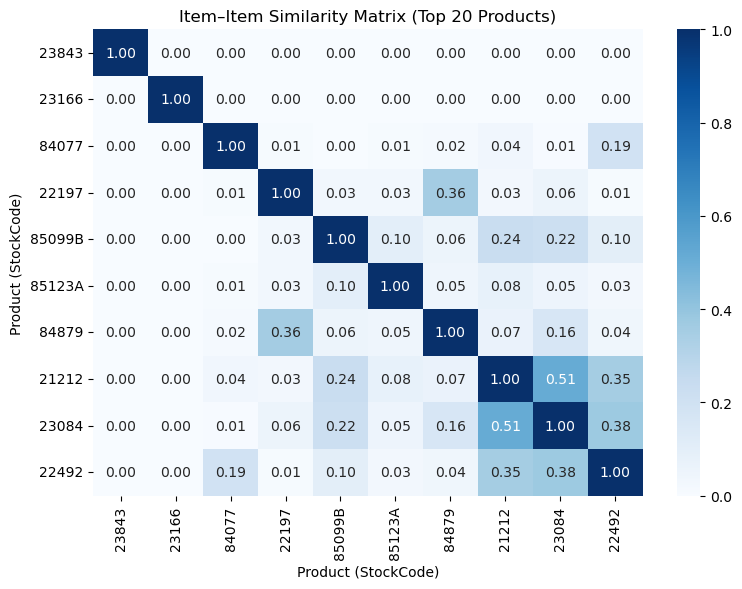


Item–item similarity matrix ready for recommendations.
Use nearest items (high similarity) for product suggestions.


In [116]:
# 8. PRODUCT RECOMMENDATION: SIMILARITY HEATMAP (Item-Item)

print("\n Product Recommendation: Similarity Matrix (Item-Item)")

# Create a pivot table: customers vs products (total quantity purchased)
item_pivot = df.pivot_table(
    index="CustomerID",
    columns="StockCode",
    values="Quantity",
    aggfunc="sum",
    fill_value=0
)

# Use top N most popular products only
top_n_products = item_pivot.sum(axis=0).sort_values(ascending=False).head(10).index
item_pivot_top = item_pivot[top_n_products]

print("Shape of item-pivot (top 10 products):", item_pivot_top.shape)

# Compute cosine similarity between products
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(item_pivot_top.T)
sim_df = pd.DataFrame(
    similarity_matrix,
    index=item_pivot_top.columns,
    columns=item_pivot_top.columns
)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(sim_df, annot=True, fmt=".2f", cmap="Blues")
plt.title("Item–Item Similarity Matrix (Top 20 Products)")
plt.xlabel("Product (StockCode)")
plt.ylabel("Product (StockCode)")
plt.tight_layout()
plt.show()

print("\nItem–item similarity matrix ready for recommendations.")
print("Use nearest items (high similarity) for product suggestions.")

#### STEP 4 Clustering Methodology

In [121]:
# Import libraries 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

# 1️ Feature Engineering: Build RFM table

# Create TotalAmount column
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

# Reference date
reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

# RFM calculation
rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,   # Recency
    "InvoiceNo": "nunique",                                     # Frequency
    "TotalAmount": "sum"                                        # Monetary
}).reset_index()

# Rename columns
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

print("\nRFM table shape:", rfm.shape)
print("\nRFM sample:")
print(rfm.head())

rfm["Frequency_log"] = np.log1p(rfm["Frequency"])
rfm["Monetary_log"] = np.log1p(rfm["Monetary"])
rfm["Recency_log"] = np.log1p(rfm["Recency"])

rfm_features = rfm[["Recency_log", "Frequency_log", "Monetary_log"]]


RFM table shape: (4338, 4)

RFM sample:
   CustomerID  Recency  Frequency  Monetary
0     12346.0      326          1  77183.60
1     12347.0        2          7   4310.00
2     12348.0       75          4   1797.24
3     12349.0       19          1   1757.55
4     12350.0      310          1    334.40


In [122]:
# 2 Standardize / Normalize RFM values

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print("\nScaled RFM feature sample:")
print(pd.DataFrame(rfm_scaled, columns=["Recency_scaled", "Frequency_scaled", "Monetary_scaled"]).head())
      
# 3 Choose Clustering Algorithm
#    [Using KMeans]

print("\nUsing KMeans clustering")



Scaled RFM feature sample:
   Recency_scaled  Frequency_scaled  Monetary_scaled
0        1.461993         -0.955214         3.706225
1       -2.038734          1.074425         1.411843
2        0.373104          0.386304         0.716489
3       -0.623086         -0.955214         0.698739
4        1.424558         -0.955214        -0.618962

Using KMeans clustering


In [148]:
# Run Clustering
# Create TotalAmount

df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

#  Create RFM

reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (reference_date - x.max()).days,  # Recency
    "InvoiceNo": "nunique",                                    # Frequency
    "TotalAmount": "sum"                                       # Monetary
}).reset_index()

rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

#  Scaling

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

#  KMeans Clustering

kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

#  Cluster Summary 

cluster_summary = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Count'})

print("\nCluster Summary:\n", cluster_summary)

#  Rank Clusters (RFM Logic)

cluster_summary['R_rank'] = cluster_summary['Recency'].rank(ascending=True)
cluster_summary['F_rank'] = cluster_summary['Frequency'].rank(ascending=True)
cluster_summary['M_rank'] = cluster_summary['Monetary'].rank(ascending=True)

print("\nCluster Summary with Ranks:\n", cluster_summary)

#  Assign Labels

cluster_labels = {}

for i in cluster_summary.index:
    r = cluster_summary.loc[i, 'R_rank']
    f = cluster_summary.loc[i, 'F_rank']
    m = cluster_summary.loc[i, 'M_rank']

    # High Value: Low R, High F, High M
    if r == 1 and f == 4 and m == 4:
        cluster_labels[i] = "High-Value"

    # At Risk: High R, Low F, Low M
    elif r == 4 and f == 1 and m == 1:
        cluster_labels[i] = "At-Risk"

    # Regular: Medium values
    elif f >= 3 and m >= 3:
        cluster_labels[i] = "Regular"

    # Occasional: Low F, Low M
    else:
        cluster_labels[i] = "Occasional"

#  Map Labels

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)
cluster_summary['Segment_Label'] = cluster_summary.index.map(cluster_labels)

print("\nFinal Cluster Labels:\n", cluster_summary)




Cluster Summary:
             Recency   Frequency       Monetary  Count
Cluster                                              
0         10.752577   28.510309   12168.264691    194
1        248.927577    1.805942     455.110716   1077
2          5.090909  109.909091  124312.306364     11
3         42.780906    4.370550    1320.981506   3090

Cluster Summary with Ranks:
             Recency   Frequency       Monetary  Count  R_rank  F_rank  M_rank
Cluster                                                                      
0         10.752577   28.510309   12168.264691    194     2.0     3.0     3.0
1        248.927577    1.805942     455.110716   1077     4.0     1.0     1.0
2          5.090909  109.909091  124312.306364     11     1.0     4.0     4.0
3         42.780906    4.370550    1320.981506   3090     3.0     2.0     2.0

Final Cluster Labels:
             Recency   Frequency       Monetary  Count  R_rank  F_rank  M_rank  \
Cluster                                               

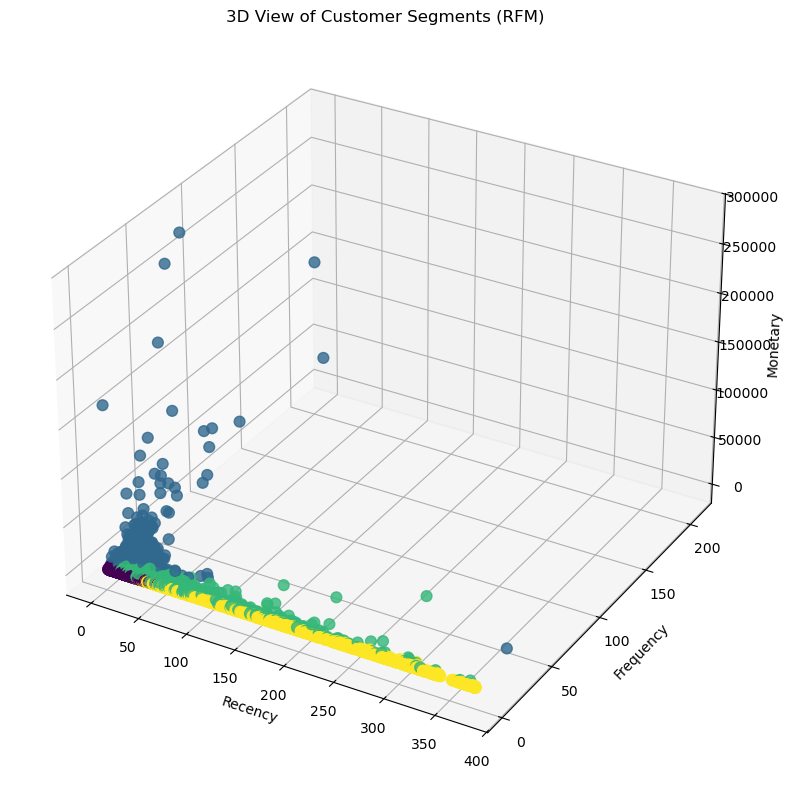

In [89]:
# 6 Visualize Clusters
# 3D scatter plot

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

segment_codes = rfm["Cluster"]
scatter = ax.scatter(
    rfm["Recency"],
    rfm["Frequency"],
    rfm["Monetary"],
    c=segment_codes,
    cmap="viridis",
    s=60,
    alpha=0.8
)

ax.set_title("3D View of Customer Segments (RFM)")
ax.set_xlabel("Recency")
ax.set_ylabel("Frequency")
ax.set_zlabel("Monetary")

plt.tight_layout()
plt.show()

In [139]:
# 7 Save the Model

joblib.dump(kmeans, "kmeans_rfm_model.pkl")
joblib.dump(scaler, "rfm_scaler.pkl")
joblib.dump(cluster_labels, "cluster_labels.pkl")

rfm.to_csv("rfm_customer_segments.csv", index=False)
cluster_summary.to_csv("rfm_cluster_summary.csv")

print("\nFiles Saved Successfully:")
print("1. kmeans_rfm_model.pkl")
print("2. rfm_scaler.pkl")
print("3. cluster_labels.pkl")
print("4. rfm_customer_segments.csv")
print("5. rfm_cluster_summary.csv")


Files Saved Successfully:
1. kmeans_rfm_model.pkl
2. rfm_scaler.pkl
3. cluster_labels.pkl
4. rfm_customer_segments.csv
5. rfm_cluster_summary.csv


In [129]:
# Save separate file for recommendation system

import pandas as pd
import joblib
from sklearn.metrics.pairwise import cosine_similarity

# Keep only needed columns

product_df = df[['StockCode', 'Description']].dropna().drop_duplicates().reset_index(drop=True)

# Customer-product pivot table

customer_product_matrix = pd.pivot_table(
    df,
    index='Description',
    columns='CustomerID',
    values='Quantity',
    aggfunc='sum',
    fill_value=0
)

# Item similarity

product_similarity_matrix = cosine_similarity(customer_product_matrix)

# Save files

product_df = pd.DataFrame({"Description": customer_product_matrix.index})
product_df.to_csv("product_similarity_data.csv", index=False)
joblib.dump(product_similarity_matrix, "product_similarity_matrix.pkl")

print("Saved:")
print("- product_similarity_data.csv")
print("- product_similarity_matrix.pkl")

Saved:
- product_similarity_data.csv
- product_similarity_matrix.pkl


#### Let's go to streamlit.....